<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/10_ML_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8. 선형 회귀 (Linear Regression)


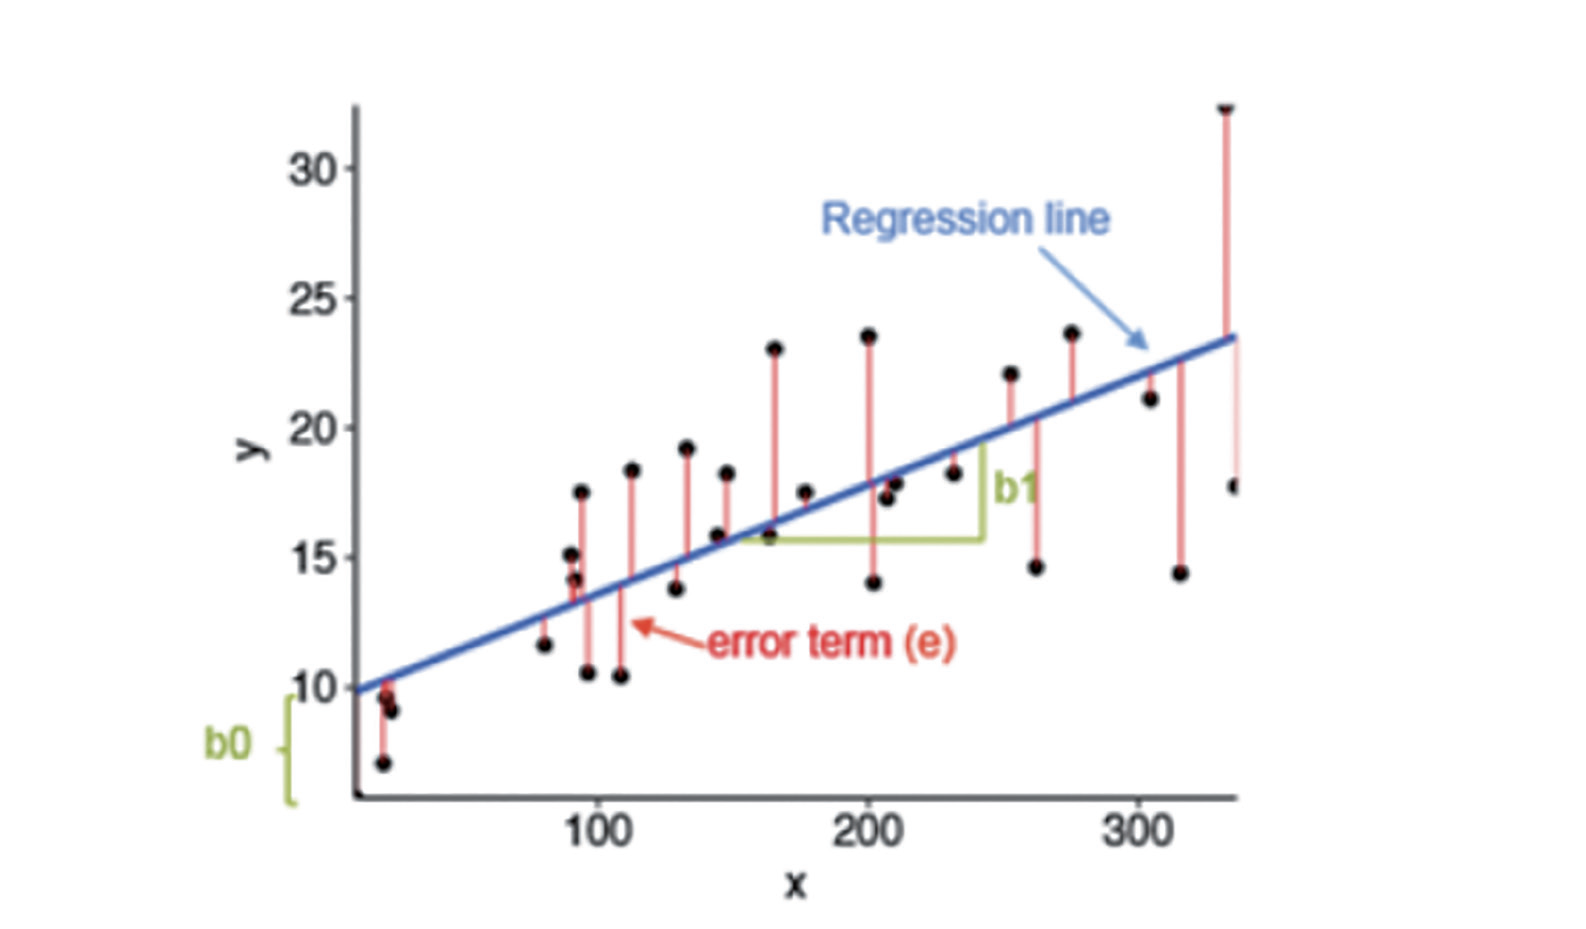

- 관측된 데이터들을 바탕으로 종석변수(결과값)와 하나 이상의 독립 변수(영향을 주는 요인) 간의 관계를 모델링하는 통계학 및 기계학습 기법
- 데이터의 경향성을 가장 잘 설명하는 직선(1차 함수)을 찾아내어 새로운 값을 예측하는 데 사용

- 수치형 독립 변수(설명 변수) X와 연속형 숫자로 이뤄진 종속 변수 Y 간의 관계를 선형으로
가정하고 이를 가장 잘 표현할 수 있는 회귀계수를 데이터로부터 추정한다.
- 종속 변수 Y를 독립 변수 X들의 선형 결합으로 표현한 모델 (선형 회귀 모델)
- 학습을 위해 종속 변수가 필요한 지도 학습


- 손실 (Loss)
  - 선형 회귀 문제는 데이터를 가장 잘 설명하는 선을 찾는 문제다.
  - 직선이 데이터를 잘 설명하는지를 판단할 수 있는 기준이 손실

https://raw.githubusercontent.com/Codecademy/datasets/master/streeteasy/manhattan.csv

- 선형 회귀 방정식
  - 단순 선형회귀의 기본방정식
  - y = wx+b
  - w : 가중치 (weight)
  - x : 독립변수
  - b : 절편 또는 bias
- 독립변수 여러개인 경우 (다중선형회귀)
  - y = w_1x_1 + w_2x_2+...

In [4]:
import pandas as pd
manhattan = pd.read_csv('https://raw.githubusercontent.com/Codecademy/datasets/master/streeteasy/manhattan.csv')
manhattan.head(50)

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood,borough
0,1545,2550,0.0,1,480,9,2.0,17,1,1,0,0,1,1,0,1,Upper East Side,Manhattan
1,2472,11500,2.0,2,2000,4,1.0,96,0,0,0,0,0,0,0,0,Greenwich Village,Manhattan
2,2919,4500,1.0,1,916,2,51.0,29,0,1,0,1,1,1,0,0,Midtown,Manhattan
3,2790,4795,1.0,1,975,3,8.0,31,0,0,0,1,1,1,0,1,Greenwich Village,Manhattan
4,3946,17500,2.0,2,4800,3,4.0,136,0,0,0,1,1,1,0,1,Soho,Manhattan
5,10817,3800,3.0,2,1100,3,5.0,101,0,0,0,0,0,0,0,0,Central Harlem,Manhattan
6,9077,1995,0.0,0,600,6,1.0,115,0,0,0,0,0,0,0,0,Midtown East,Manhattan
7,5150,2995,0.0,1,579,6,21.0,33,0,0,0,0,0,0,0,0,Battery Park City,Manhattan
8,9507,15000,2.0,2,1715,0,30.0,2,0,0,0,0,0,0,0,0,Flatiron,Manhattan
9,1437,4650,1.0,1,915,5,5.0,106,0,0,0,0,0,0,0,0,Upper East Side,Manhattan


In [8]:
manhattan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rental_id         3539 non-null   int64  
 1   rent              3539 non-null   int64  
 2   bedrooms          3539 non-null   float64
 3   bathrooms         3539 non-null   int64  
 4   size_sqft         3539 non-null   int64  
 5   min_to_subway     3539 non-null   int64  
 6   floor             3539 non-null   float64
 7   building_age_yrs  3539 non-null   int64  
 8   no_fee            3539 non-null   int64  
 9   has_roofdeck      3539 non-null   int64  
 10  has_washer_dryer  3539 non-null   int64  
 11  has_doorman       3539 non-null   int64  
 12  has_elevator      3539 non-null   int64  
 13  has_dishwasher    3539 non-null   int64  
 14  has_patio         3539 non-null   int64  
 15  has_gym           3539 non-null   int64  
 16  neighborhood      3539 non-null   object 


- 상관관계
  - 독립변수와 종속변수 간의 상관관계를 계산하고 내림차순 출력

In [9]:
matrix = manhattan.iloc[:,:-2]
# sol2
# numeric_df = manhattan.select_dtypes(include=['number'])
corr_matrix = matrix.corr()
corr_matrix['rent'].sort_values(ascending=False)

,rent
rent,1.000000
size_sqft,0.857954
bathrooms,0.769474
bedrooms,0.638336
floor,0.215867
has_washer_dryer,0.053873
has_dishwasher,0.052241
has_elevator,0.051860
has_gym,0.040609
has_roofdeck,0.035165


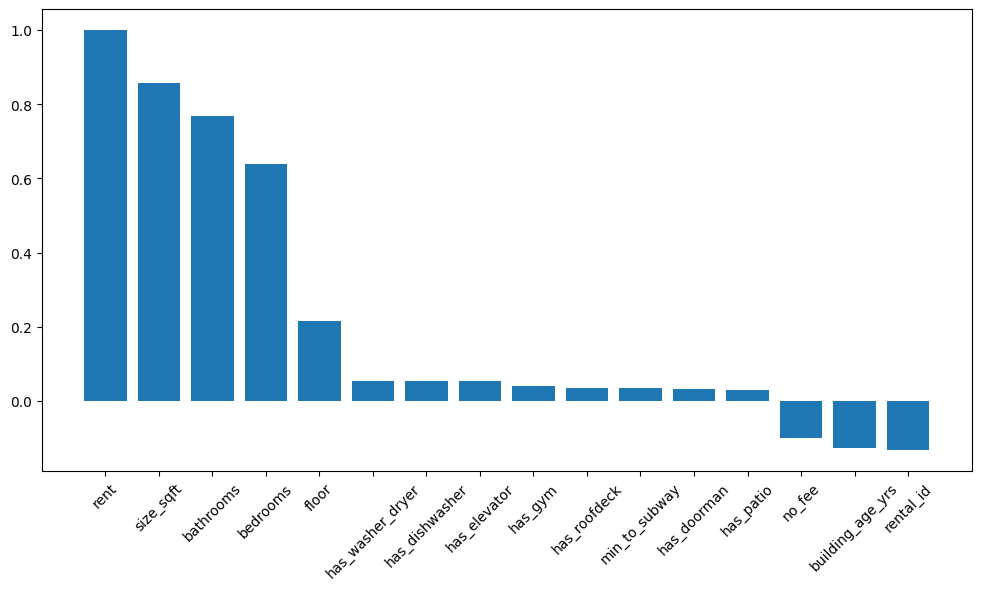

In [10]:
import matplotlib.pyplot as plt

corr_df = pd.DataFrame(corr_matrix['rent'].sort_values(ascending=False))
plt.figure(figsize=(12,6))
plt.bar(corr_df.index, corr_df['rent'])
plt.xticks(rotation=45)
plt.show()

- 피처 선택

In [11]:
X = manhattan[['size_sqft','bathrooms','bedrooms', 'floor',
'has_washer_dryer', 'has_dishwasher','has_elevator']]
y = manhattan[['rent']]

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,size_sqft,bathrooms,bedrooms,floor,has_washer_dryer,has_dishwasher,has_elevator
532,1034,2,2.0,10.0,0,0,0
3386,1510,2,2.0,8.0,0,0,0
2163,885,1,1.0,6.0,0,0,0
1813,1100,1,2.0,19.0,0,0,0
842,971,2,2.0,9.0,0,0,0


- 모델학습

In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("coef: ", lr.coef_)
print('intercept: ', lr.intercept_)

coef:  [[   4.99127899 1201.97080535 -356.70443765   32.44975818   69.90330536
    -1.68501497   29.83999551]]
intercept:  [-1123.25917512]


In [15]:
y_pred = lr.predict(X_test)

In [16]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)
print('mse :', mse)
print('rmse :', rmse)
print('mae :', mae)
print('r2score :', r2score)

mse : 2471457.3112621717
rmse : 1572.0869286595355
mae : 967.0461593118893
r2score : 0.7379760242365376


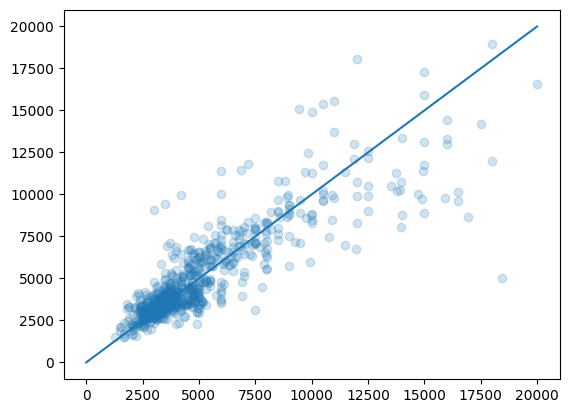

In [23]:
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([0,20000], [0,20000])
plt.show()

> ### 회귀 (Regression)지표 4가지
  - MSE
  - RMSE (Root Mean Squared Error)
  - MAE (Mean Absolute Error, 평균 절대 오차)
  - R^2 (R-squared,결정계수)

### 다항 회귀 모델
- 데이터이 분포가 직선이 아니라 곡선의 형태이면?

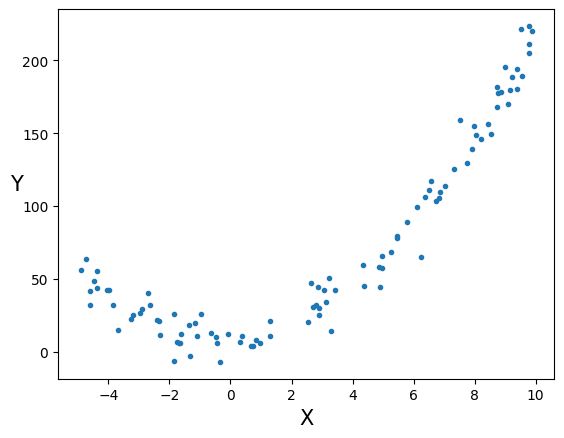

In [25]:
import numpy as np
import matplotlib.pyplot as plt

X = -5 + 15*np.random.rand(100,1)
noise = 10 * np.random.randn(100,1)

y = 2*X**2 + X+10+noise

plt.plot(X,y,".")
plt.ylabel("Y", fontsize=15, rotation=0)
plt.xlabel("X", fontsize=15)
plt.show()

In [26]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

print(X_poly[:10])

[[ 7.31931858 53.57242453]
 [ 4.38483851 19.22680876]
 [ 0.37741979  0.1424457 ]
 [-1.15285279  1.32906955]
 [ 6.72683937 45.2503679 ]
 [ 9.77708418 95.59137503]
 [ 7.7392309  59.89569494]
 [-0.43681013  0.19080309]
 [ 6.5705862  43.17260304]
 [ 9.22200621 85.04539845]]


In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_poly,y)

print(lr.intercept_, lr.coef_)

[9.6623828] [[1.02322414 2.00627622]]


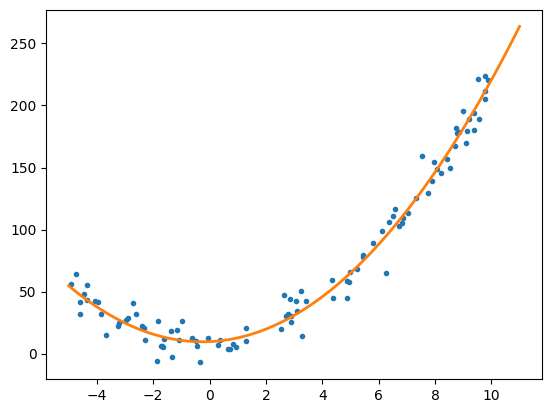

In [28]:
X_new = np.linspace(-5,11,100).reshape(100,1)
X_new_poly = poly_features.transform(X_new)
y_new = lr.predict(X_new_poly)

plt.plot(X,y,".")
plt.plot(X_new,y_new, linewidth=2, label="Polynominal Predictions")
plt.show()